Ab hum Machine Learning Model Training ka sabse pehla aur zaroori step kar rahe hain: Dataset ko Input ($X$) aur Output ($y$) mein divide karna.

$X$ (Independent Features / Inputs): Woh saari information jo hum model ko denge (jaise Temperature, Humidity, Rain, FFMC, etc.).
$y$ (Dependent Feature / Target Output): Jo cheez hume model se predict karwani hai (hamaara final answer).


## Feature selection and model training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('final_forest_fire_dataset.csv')
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [4]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='str')

In [5]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

FWI column ko kyun hataya?
Is project ka main maksad hai ki mausam ke hisab se yeh predict karna ki FWI (Fire Weather Index) kitna hoga.

FWI hamara Target (Answer) hai!
Isiliye:
y = df['FWI']: FWI ko humne alag se Output ($y$) bana liya.
X = df.drop('FWI', axis=1): Baki saare columns ko humne Input ($X$) bana liya.


In [6]:
#independent and depedent features

X=df.drop('FWI', axis=1)
y=df['FWI']

In [7]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0



### 1. $y_{train}$ kyun chahiye? (Model ko Padhane ke liye)

Model koi insaan nahi hai jisko pehle se sab pata ho. Shuru mein model ko kuch nahi aata.
* Hum model ko bolte hain: 
  *"Dekho, jab Temperature 32 tha aur Baarish 0 thi ($X_{train}$), tab FWI ki value **12.5** thi ($y_{train}$)."*
* Model apna formula lagata hai. Agar model ne 12.5 ki jagah 20 socha, toh model ko pata chalta hai ki *"Arre, mera answer galat hai, actual answer toh 12.5 ($y_{train}$) hai!"* 
* Fir model apne mathematical formula (weights/slopes) ko adjust karta hai.

> **Conclusion for $y_{train}$:** Agar model ke paas $y_{train}$ (sahi answer) hi nahi hoga, toh **model ko pata hi kaise chalega ki woh sahi seekh raha hai ya galat?** Isliye sikhate waqt question ($X_{train}$) aur answer ($y_{train}$) dono dene padte hain.

---

### 2. $y_{test}$ kyun chahiye? (Teacher ke paas Answer Sheet)

Ab aayi **Exam ki baari**!
1. **Model ko sirf Question Paper diya:** Humne model ko sirf **`X_test`** diya aur bola — *"Yeh lo naya mausam ka data, ab batao FWI kitna aayega?"*
2. **Model ne apna answer diya:** Model jo khud answer nikalta hai, use hum kehte hain **`y_pred`** (Predicted values).
3. **Teacher ne marks kaise diye?** 
   * Ab hume (Data Scientist ko) kaise pata chalega ki model ne sahi answer nikala ya bekaar answer nikala? Model 90% accurate hai ya 20%?
   * Yeh check karne ke liye hume **Asli sach (Actual Truth)** chahiye na!
   * Woh Asli Sach hi **`y_test`** hai!

Hum compare karte hain:
$$\text{Model ka Answer } (y_{pred}) \quad \text{VS} \quad \text{Asli Answer } (y_{test})$$

* Agar actual $y_{test} = 15$ tha, aur model ne $y_{pred} = 14.8$ predict kiya $\rightarrow$ **Wah! Model pass ho gaya, error bohot kam hai.**
* Agar actual $y_{test} = 15$ tha, aur model ne $y_{pred} = 65$ bol diya $\rightarrow$ **Model fail ho gaya, bekaar predict kiya.**

---

### Summary (Ek Nazar Mein):
| Variable | Kya hai? | Asli Maksad |
| :--- | :--- | :--- |
| **$X_{train}$** | Training Questions (Inputs) | Model ko padhana |
| **$y_{train}$** | Training Answers (Outputs) | Model ko batana ki sahi answer kya aana chahiye |
| **$X_{test}$** | Exam ka Question Paper | Model ka test lena |
| **$y_{test}$** | Exam ki **Master Answer Key** | Model ke answers check karke uska Accuracy Score ($R^2$ / MSE) nikalna |

Agar hamaare paas $y_{test}$ na ho, toh hum kabhi pata hi nahi kar payenge ki hamaara model achha bana hai ya galat!

In [8]:
#train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_tests=train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
X_train.shape

(182, 11)

In [10]:
## feature selection based on correlation

X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

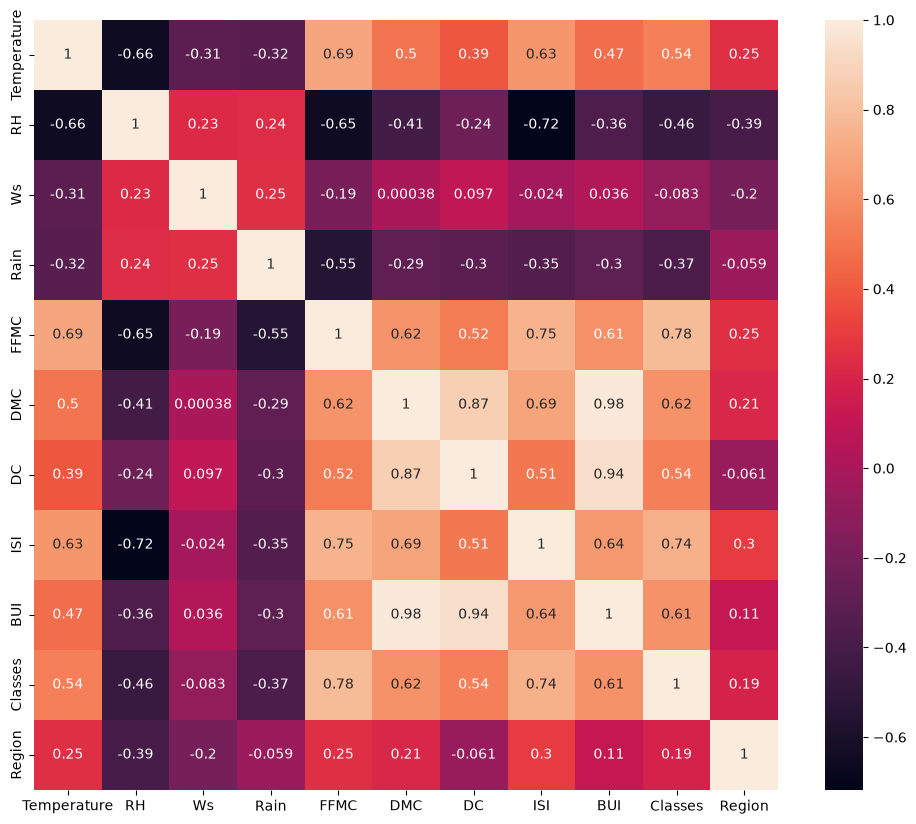

In [11]:
## check for multicollinearity

plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)

### Ab sawal hai: "Iske baad kya hoga?" (The Big Picture)

Jaise hi aap high correlation wale features ko drop kar denge, agle **4 main steps** honge:

```text
Feature Drop (Multicollinearity Done)
           │
           ▼
1. Feature Scaling (StandardScaler) ──► Sabhi numbers ko ek scale par lana
           │
           ▼
2. Model Training (.fit())          ──► Linear Regression, Ridge, Lasso ko sikhana
           │
           ▼
3. Prediction & Evaluation          ──► Test lena (R² Score, MAE, MSE check karna)
           │
           ▼
4. Model Saving (Pickling)          ──► Model ko .pkl file me save karna (Web App ke liye)
```

---

### Step 1: Feature Scaling (`StandardScaler`) — *Agla Sabse Bada Step*
* **Kyun zaroori hai:** 
  Aapke features ki values bohot alag-alag hain:
  * `Rain` ki value hai: **0 se 16**
  * `DC` ki value hai: **7 se 220 tak!**
  Linear Regression mein bade numbers (DC) chhote numbers (Rain) ko daba dete hain.
* **Isliye Sir kya karenge:**
  `StandardScaler` use karke sabhi features ko ek barabar scale (mean = 0, standard deviation = 1) par le aayenge:
  ```python
  from sklearn.preprocessing import StandardScaler
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  ```
  *(Dhyan dijiyega: `X_test` par sirf `transform` hota hai, `fit_transform` nahi, taaki data leak na ho).*

---

### Step 2: Model Training (`.fit()`)
Ab aayegi asli Machine Learning! Sir alag-alag algorithms ko data padhayenge:
1. **Simple Linear Regression**
2. **Lasso Regression (L1)** (Overfitting rokne ke liye)
3. **Ridge Regression (L2)** (Overfitting rokne ke liye)
4. **ElasticNet Regression**

Code aasan hoga:
```python
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train_scaled, y_train)
```

---

### Step 3: Model ka Exam (Prediction & Performance Check)
Model se `X_test` ka answer nikalwayenge aur actual `y_test` se match karke score check karenge:
```python
y_pred = regression.predict(X_test_scaled)
```
Yahan check hoga:
* **$R^2$ Score (Accuracy):** Ki model ne kitne percent sahi pattern pakda (jaise 95%+ R² score aayega).
* **MAE (Mean Absolute Error) & MSE:** Ki model ke answer mein kitna average error/galti hai.

---

### Step 4: Model ko Save karna (`pickle`)
Aakhri step mein sir best model ko aur scaler ko ek file banakar save kar lenge (`scaler.pkl` aur `model.pkl`), taaki baad mein Flask ya Streamlit se iski **Web Application** banayi ja sake!

Aap bilkul sahi track par hain, ab video mein sir aage scaling aur model fitting shuru karenge!

In [15]:
def correlation(dataset, threshold):
    col_corr = set()  # 1. Ek khaali set banaya jisme drop karne wale columns ke naam store honge
    corr_matrix = dataset.corr() # 2. Correlation table calculate kar li

    # 3. Table ke rows aur columns ko scan karne ke liye loops
    for i in range(len(corr_matrix.columns)):
        for j in range(i):  # <-- BOHOT IMPORTANT: Sirf aadhi table scan karega
            
            # 4. Agar do features ka correlation threshold (jaise 0.85) se bada hai
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i] # Us column ka naam nikalo
                col_corr.add(colname)            # Aur list me daal do

    return col_corr  # 5. Saare high correlation wale columns wapas mil gaye


In [19]:
## threshold - domain expertise


corr_features = correlation(X_train, 0.85)

In [20]:
# drop features when correlation is more than 0.85

X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)


In [22]:
X_train.shape, X_test.shape

((182, 9), (61, 9))

In [ ]:
## Feature scaling and standardization 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.04,-0.17, 0.01,..., 4.84, 0.4 ,-0.39]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[28.82,14.8 ,13.67,..., 7.68, 5.77, 4.49]"


In [ ]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)

plt.title("X train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After scaling')
